In [4]:
from pathlib import Path
import sys

# En un entorno de Jupyter Notebook, usando Path.cwd() evitamos depender de __file__
ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

In [5]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from dqn import DQNAgent


Episode 50/1000 | Avg Reward: -200.00 | Epsilon: 0.7783 | Buffer: 10000
Episode 100/1000 | Avg Reward: -200.00 | Epsilon: 0.6058 | Buffer: 20000
Episode 150/1000 | Avg Reward: -200.00 | Epsilon: 0.4715 | Buffer: 30000
Episode 200/1000 | Avg Reward: -200.00 | Epsilon: 0.3670 | Buffer: 40000
Episode 250/1000 | Avg Reward: -200.00 | Epsilon: 0.2856 | Buffer: 50000
Episode 300/1000 | Avg Reward: -200.00 | Epsilon: 0.2223 | Buffer: 60000
Episode 350/1000 | Avg Reward: -200.00 | Epsilon: 0.1730 | Buffer: 70000
Episode 400/1000 | Avg Reward: -200.00 | Epsilon: 0.1347 | Buffer: 80000
Episode 450/1000 | Avg Reward: -200.00 | Epsilon: 0.1048 | Buffer: 90000
Episode 500/1000 | Avg Reward: -200.00 | Epsilon: 0.0816 | Buffer: 100000
Episode 550/1000 | Avg Reward: -200.00 | Epsilon: 0.0635 | Buffer: 100000
Episode 600/1000 | Avg Reward: -200.00 | Epsilon: 0.0494 | Buffer: 100000
Episode 650/1000 | Avg Reward: -200.00 | Epsilon: 0.0385 | Buffer: 100000
Episode 700/1000 | Avg Reward: -200.00 | Epsilon

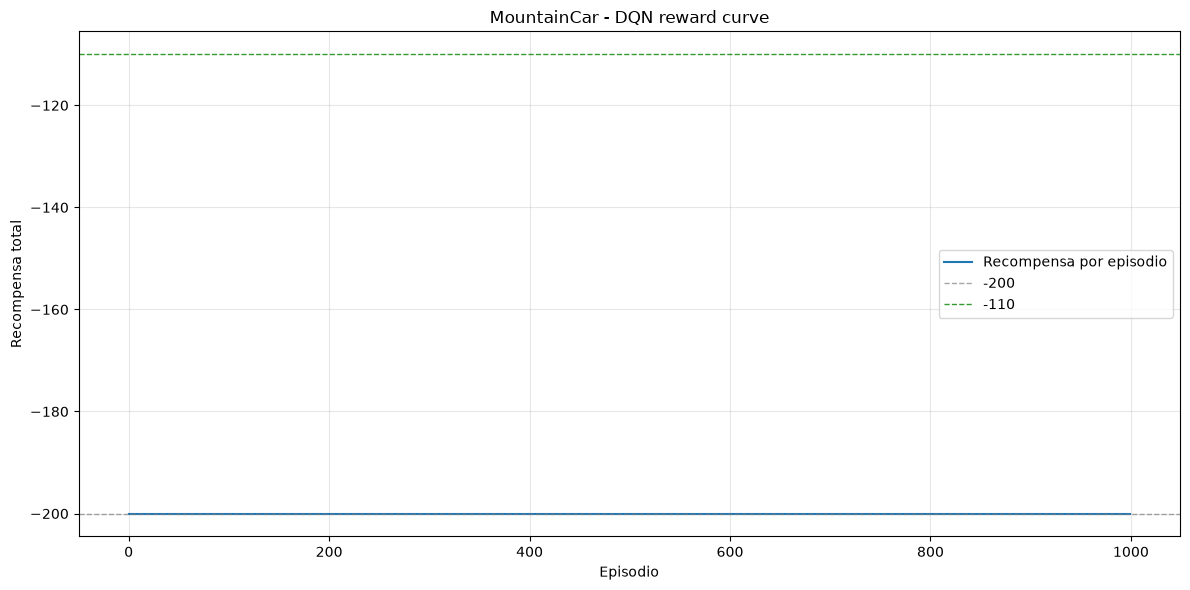

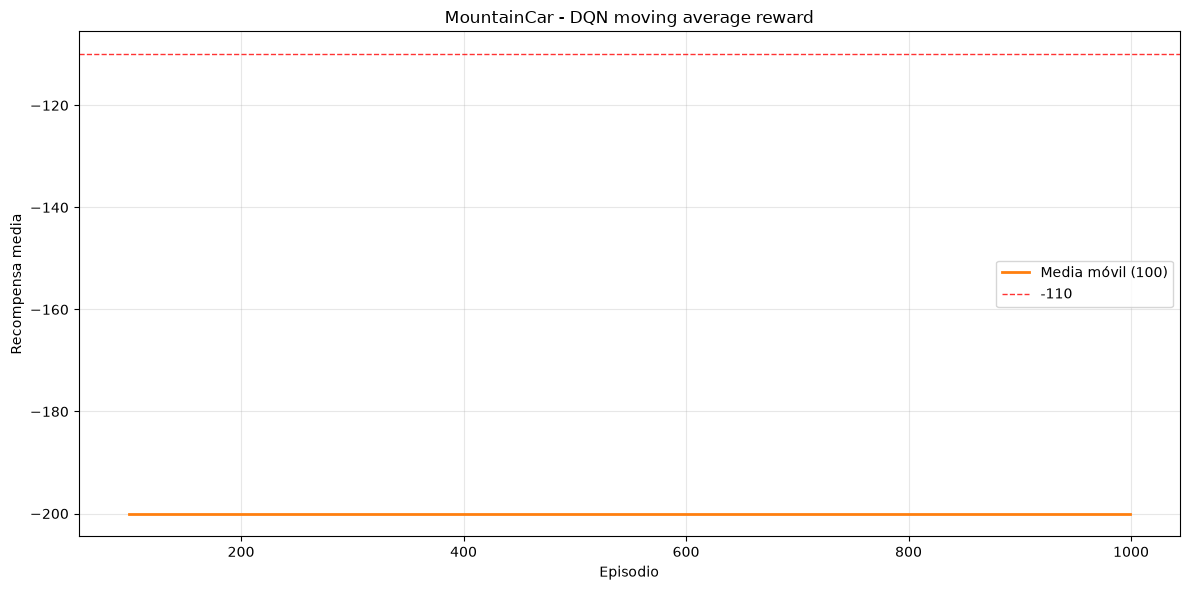

In [6]:
# Entrenamiento del agente DQN
SAVE_PATH = ROOT / "saves" / "dqn_tuned.pt"

agent = DQNAgent(
    "MountainCar-v0",
    lr=1e-3,
    gamma=0.99,
    epsilon_decay=0.995,
    batch_size=64,
    hidden=64,
)

rewards = agent.train(total_episodes=1000, log_interval=50)
agent.save(SAVE_PATH)

print(f"avg_last_50 = {float(np.mean(rewards[-50:])):.3f}")
print(f"avg_last_100 = {float(np.mean(rewards[-100:])):.3f}")
print(f"last10 = {rewards[-10:]}")

# Curva de recompensa por episodio
plt.figure(figsize=(12, 6))
plt.plot(rewards, color="tab:blue", linewidth=1.5, label="Recompensa por episodio")
plt.axhline(-200, color="gray", linestyle="--", linewidth=1, alpha=0.7, label="-200")
plt.axhline(-110, color="green", linestyle="--", linewidth=1, alpha=0.8, label="-110")
plt.title("MountainCar - DQN reward curve")
plt.xlabel("Episodio")
plt.ylabel("Recompensa total")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("dqn_rewards.png", dpi=200)
plt.show()

# Media móvil para ver la tendencia real
window = 100
moving_avg = np.convolve(rewards, np.ones(window) / window, mode="valid")
xs = np.arange(window - 1, len(rewards))

plt.figure(figsize=(12, 6))
plt.plot(xs, moving_avg, color="tab:orange", linewidth=2, label=f"Media móvil ({window})")
plt.axhline(-110, color="red", linestyle="--", linewidth=1, alpha=0.8, label="-110")
plt.title("MountainCar - DQN moving average reward")
plt.xlabel("Episodio")
plt.ylabel("Recompensa media")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("dqn_moving_average.png", dpi=200)
plt.show()
